### HW2

#### Preliminary part. WikIR download 

In [10]:
import pandas as pd
import os
import numpy as np

In [ ]:
path_test_queries = "C:\\Users\\ASUS\\Documents\\YSDA_4sem\\Information Retrieval\\ysda_information_retrieval_s26\\src\\datasets\\wikIR1k\\test\\queries.csv"

df = pd.read_csv(path_test_queries)
df.head()

,id_left,text_left
0,158491,southern methodist university
1,5728,halakha
2,13554,chief justice of the united states
3,32674,patsy cline
4,406391,dierks bentley


### 1. Provide basic statistics for the test queries (5)
* num of queries
* query length in words
* num of relevant docs per query

In [7]:
len(df)

100

В датасете - 100 запросов.

Рассмотрим распределение длин запросов, разброс, а также длину среднего и медианного запроса в словах

In [17]:
df['len']= df.text_left.apply(lambda x: len(str(x).split(" ")))
df

,id_left,text_left,len
0,158491,southern methodist university,3
1,5728,halakha,1
2,13554,chief justice of the united states,6
3,32674,patsy cline,2
4,406391,dierks bentley,2
...,...,...,...
95,679227,hiv aids,2
96,2136797,maren morris,2
97,5622,homer,1
98,1313598,south pole,2


array([[<Axes: title={'center': 'len'}>]], dtype=object)

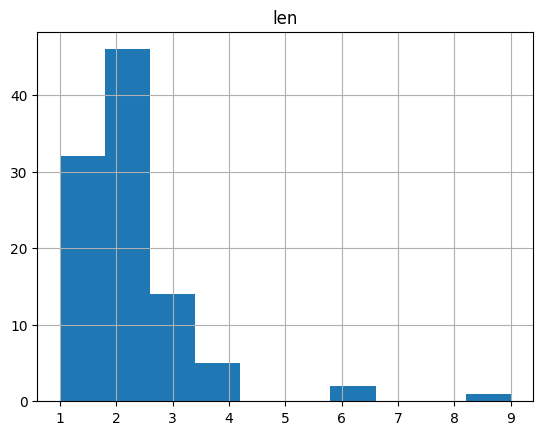

In [19]:
df.hist(column='len')

In [21]:
df.len.describe()

count    100.000000
mean       2.070000
std        1.216511
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        9.000000
Name: len, dtype: float64

In [24]:
df.len.quantile(0.95), df.len.median()

(4.0, 2.0)

* В данном датасете 95% запросов состоят из не более, чем 4 слов, \
* 75% запросов состоят из не более, чем 2 слов.
* Медианный запрос состоит из двух слов.

теперь посмотрим на те же статистики для числа релевантных запросу документах.
Информация о релевантных запросу документах содержится в BM25.qrels.csv.

In [26]:
path_test_qrels = "C:\\Users\\ASUS\\Documents\\YSDA_4sem\\Information Retrieval\\ysda_information_retrieval_s26\\src\\datasets\\wikIR1k\\test\\BM25.qrels.csv"

qrels_df = pd.read_csv(path_test_qrels)
qrels_df.head()

,Unnamed: 0,id_left,id_right,label
0,0,158491,625257,1
1,1,158491,663828,1
2,2,158491,607552,1
3,3,158491,93661,1
4,4,158491,1902136,1


In [ ]:
merged_df = df.merge(qrels_df, how='left', on='id_left').groupby('id_left')['label'].count()
merged_df

id_left
720        101
2161       101
2591       101
4900       101
5115       101
          ... 
1313598    101
1313611    101
1368508    101
1897191    101
2136797    101
Name: label, Length: 100, dtype: int64

Видим, что на каждый документ в test eсть 101 документ в выдаче с разной степенью релевантности.

In [49]:
merged_df = df.merge(qrels_df, how='left', on='id_left')
a_bit_relevant_subset = merged_df[merged_df.label == 1].groupby('id_left')['label'].count()
a_bit_relevant_subset

id_left
720        100
2161       100
2591       100
4900       100
5115       100
          ... 
1313598    100
1313611    100
1368508    100
1897191    100
2136797    100
Name: label, Length: 100, dtype: int64

Видим, что на каждый запрос есть 100 релевантных документов и 1 нерелеватный.

<Axes: xlabel='label'>

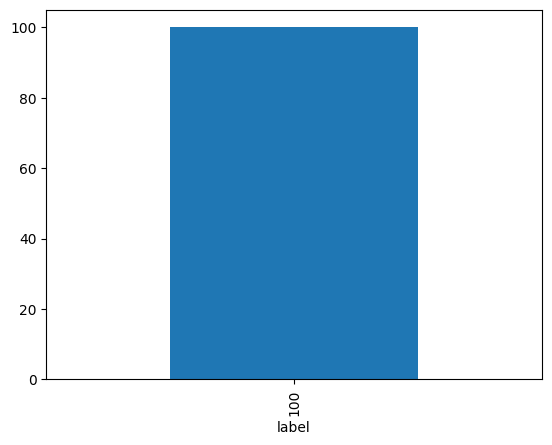

In [50]:
a_bit_relevant_subset.value_counts().sort_index().plot(kind='bar')

#### 2. Run test queries on three collection variants using tf.idf and Rank-BM25: original, stemmed, lemmatized 
(don’t forget to process queries accordingly). Estimate the query execution time. Store the results in the TREC runs format.

In [51]:
%pip install rank_bm25

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\ASUS\.pyenv\pyenv-win\versions\3.11.4\python.exe -m pip install --upgrade pip


In [ ]:
text_left = d